# <b>Leverage Portfolio Research</b>

Cluster the long-history ETF universe, select one representative per cluster, then run the corrected bootstrap backtest with explicit financing, liquidation, and pathwise risk metrics.

Selected representatives: ['VT', 'BND', 'SGOV', 'GLD', 'GSG']


tickers                             [VT, BND, SGOV, GLD, GSG]
start_value                                          100000.0
simulation_years                                           10
n_sims                                                   2000
optimisation_lookback_years                                 3
simulation_history_years                                   20
block_size                                                 60
leverage                                                  2.0
leverage_rebalance_modes       [daily, weekly, monthly, None]
band                                                     0.25
hard_cap                                                  4.0
spread                                                   0.01
min_weight                                                0.1
max_weight                                                0.4
cov_method                                                oas
cov_params                                  {'jitter': 1e-08}
expected

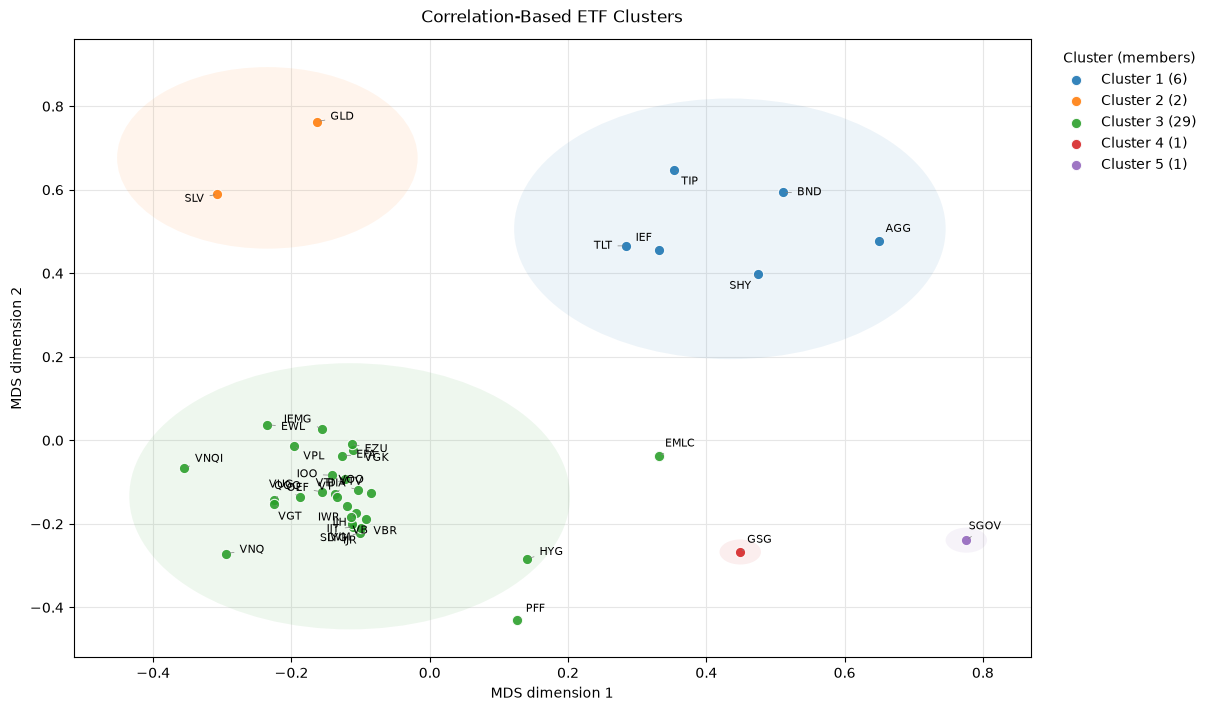

In [1]:
from pathlib import Path

import pandas as pd

from helpers.clustering import cluster_select_representatives_from_csv, visualize_clusters
from helpers.fetch import load_data
from run_research import ResearchConfig, run

N_CLUSTERS = 5
MIN_HISTORY_YEARS = 20

# initial clustering
selected_tickers, clusters = cluster_select_representatives_from_csv(
    "data/etf_universe.csv",
    n_clusters=N_CLUSTERS,
    distance_metric = "1-abs_corr",
    min_history_years=MIN_HISTORY_YEARS,
)

# replace VOO with VT if present in the selected tickers (i don't want too much US exposure!)
selected_tickers = ["VT" if ticker == "VOO" else ticker for ticker in selected_tickers]


cluster_tickers = sorted(ticker for members in clusters.values() for ticker in members)
end_date = pd.Timestamp.today().strftime("%Y-%m-%d")
start_date = (pd.Timestamp.today() - pd.DateOffset(years=MIN_HISTORY_YEARS)).strftime("%Y-%m-%d")

# load the price data for the cluster tickers and visualize the clusters
cluster_prices = pd.concat(
    [load_data(ticker, start_date, end_date)["adj close"].rename(ticker) for ticker in cluster_tickers],
    axis=1,
    join="inner",
)

#visualize clusters using MDS
visualize_clusters(clusters, returns=cluster_prices.pct_change().dropna(), figsize=(12, 7))


# settings
CONFIG = ResearchConfig(
    tickers=selected_tickers,
    start_value=100_000.0,
    simulation_years=10,
    n_sims=2000,
    optimisation_lookback_years=3,
    simulation_history_years=20,
    block_size=60,
    leverage=2.0,
    leverage_rebalance_modes=["daily", "weekly", "monthly", None],
    band=0.25,
    hard_cap=4.0,
    spread=0.01,
    min_weight=0.10,
    max_weight=0.40,
    cov_method="oas",
    cov_params={"jitter": 1e-8},
    expected_return_method="mean",
    seed=1,
)

print("Selected representatives:", selected_tickers)
pd.Series(CONFIG.__dict__ | {"n_days": CONFIG.n_days}, name="value")

## <b>Run</b>

The bootstrap samples 60-day blocks of asset returns and EFFR jointly from up to 20 years of common history.

Target portfolio weights use a separate 3-year historical warm-up, are recalculated monthly, and are constrained to 10%-40% per selected asset. A target decided at date $t$ applies from the next return observation.

Between monthly rebalances, each asset holding compounds independently and portfolio weights drift naturally. The resulting portfolio return is then reused across all leverage-reset modes.

A non-positive leveraged account is liquidated to zero and retained in all summaries.

In [2]:
# This writes all Parquet paths, summary CSVs, diagnostics, and run_config.json.
run(CONFIG, output_dir=Path("output"))

/Users/giacomomaggiore/Desktop/coding/leverage-api-api/.venv/lib/python3.12/site-packages/pypfopt/base_optimizer.py:307: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  self._opt.solve(
/Users/giacomomaggiore/Desktop/coding/leverage-api-api/.venv/lib/python3.12/site-packages/pypfopt/base_optimizer.py:307: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  self._opt.solve(
/Users/giacomomaggiore/Desktop/coding/leverage-api-api/.venv/lib/python3.12/site-packages/pypfopt/base_optimizer.py:307: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  self._opt.solve(
/Users/giacomomaggiore/Desktop/coding/leverage-api-api/.venv/lib/python3.12/site-packages/pypfopt/base_optimizer.py:307: UserWarning: Solution may be inaccur

## <b> Summaries</b>

CAGR is calculated independently for each surviving path from the configured starting capital. 

Drawdown includes starting capital as the initial peak. 

Ruined paths have a -100% drawdown, no CAGR or volatility estimate, and remain in terminal-value and ruin-rate statistics.

In [3]:
summary_files = [
    "summary_unlevered.csv",
    "summary_leveraged_daily.csv",
    "summary_leveraged_weekly.csv",
    "summary_leveraged_monthly.csv",
    "summary_leveraged_band.csv",
]

summaries = {
    name.removeprefix("summary_").removesuffix(".csv"): pd.read_csv(Path("output") / name)
    for name in summary_files
}

display_cols = [
    "run",
    "strategy",
    "cagr_q01",
    "cagr_q50",
    "ann_std_q50",
    "max_drawdown_q50",
    "terminal_q01",
    "terminal_q50",
    "terminal_q99",
    "cagr_mean",
    "max_drawdown_q01"]

aggregate_summary = pd.concat(summaries, names=["run"]).reset_index()
display_summary = aggregate_summary[display_cols]
display(display_summary[display_cols].sort_values(by=["run", "strategy"]))

#display only unlever market cap and leveraged daily equal weight
display_summary = display_summary[display_summary["run"].isin(["unlevered", "leveraged_monthly"])]
display_summary = display_summary[display_summary["strategy"].isin(["equal_weight", "market_cap", "max_sharpe"])]
display(display_summary[display_cols].sort_values(by=["run", "strategy"]))

,run,strategy,cagr_q01,cagr_q50,ann_std_q50,max_drawdown_q50,terminal_q01,terminal_q50,terminal_q99,cagr_mean,max_drawdown_q01
19,leveraged_band,equal_weight,-0.086,0.068,0.167,-0.373,40796.0,193305.0,563097.0,0.066,-0.757
18,leveraged_band,market_cap,-0.180,0.096,0.379,-0.660,13778.0,250056.0,2464359.0,0.097,-0.955
17,leveraged_band,max_sharpe,-0.055,0.077,0.151,-0.317,56966.0,209439.0,577104.0,0.075,-0.630
16,leveraged_band,min_variance,-0.033,0.047,0.090,-0.207,71706.0,159034.0,273975.0,0.046,-0.495
7,leveraged_daily,equal_weight,-0.081,0.069,0.177,-0.394,42936.0,194754.0,669996.0,0.069,-0.743
6,leveraged_daily,market_cap,-0.195,0.091,0.399,-0.689,11424.0,238800.0,3083311.0,0.094,-0.960
5,leveraged_daily,max_sharpe,-0.055,0.079,0.162,-0.340,56592.0,213741.0,678627.0,0.078,-0.617
4,leveraged_daily,min_variance,-0.030,0.046,0.094,-0.219,73807.0,157524.0,302764.0,0.046,-0.471
15,leveraged_monthly,equal_weight,-0.083,0.069,0.179,-0.398,42151.0,195597.0,673166.0,0.069,-0.753
14,leveraged_monthly,market_cap,-0.192,0.098,0.421,-0.698,11831.0,254071.0,3154480.0,0.101,-0.959


,run,strategy,cagr_q01,cagr_q50,ann_std_q50,max_drawdown_q50,terminal_q01,terminal_q50,terminal_q99,cagr_mean,max_drawdown_q01
15,leveraged_monthly,equal_weight,-0.083,0.069,0.179,-0.398,42151.0,195597.0,673166.0,0.069,-0.753
14,leveraged_monthly,market_cap,-0.192,0.098,0.421,-0.698,11831.0,254071.0,3154480.0,0.101,-0.959
13,leveraged_monthly,max_sharpe,-0.055,0.080,0.163,-0.343,56540.0,215513.0,681613.0,0.079,-0.634
3,unlevered,equal_weight,-0.026,0.052,0.088,-0.205,77199.0,165715.0,306642.0,0.051,-0.453
2,unlevered,market_cap,-0.061,0.079,0.200,-0.396,53377.0,214768.0,745090.0,0.080,-0.727
1,unlevered,max_sharpe,-0.013,0.056,0.081,-0.171,87948.0,172180.0,312896.0,0.055,-0.339


## Weight Diagnostics

Average weights reveal whether low volatility is mostly an SGOV allocation. The sensitivity table reruns capped max-Sharpe weights with historical mean, EMA, and equal expected returns; the equal-return case removes cross-asset return forecasts.

In [4]:
average_weights = pd.read_csv("output/average_weights_summary.csv")
sgov_weights = average_weights.query("ticker == 'SGOV'").sort_values("strategy")
max_sharpe_sensitivity = pd.read_csv("output/max_sharpe_sensitivity.csv")

display(sgov_weights)
display(max_sharpe_sensitivity.pivot(index="ticker", columns="expected_return_method", values="weight"))

,strategy,ticker,average_weight
3,equal_weight,SGOV,0.200000
8,market_cap,SGOV,0.000000
13,max_sharpe,SGOV,0.235277
18,min_variance,SGOV,0.399997


expected_return_method,ema,equal,mean
ticker,,,
BND,0.24385,0.3,0.26589
GLD,0.10872,0.1,0.12750
GSG,0.14530,0.1,0.10000
SGOV,0.40000,0.4,0.40000
VT,0.10213,0.1,0.10661


## Interpretation

Terminal quantiles include liquidations. 

CAGR and annualized volatility are conditional on survival because they are undefined after non-positive equity. 

Compare `ruin_rate` first, then terminal values, CAGR, drawdown, and volatility under the same horizon and rebalance assumptions. 

In [5]:
run_config = pd.read_json("output/run_config.json", typ="series")
run_config

tickers                                 [VT, BND, SGOV, GLD, GSG]
start_value                                              100000.0
simulation_years                                               10
n_sims                                                       2000
optimisation_lookback_years                                     3
simulation_history_years                                       20
block_size                                                     60
leverage                                                      2.0
leverage_rebalance_modes           [daily, weekly, monthly, None]
band                                                         0.25
hard_cap                                                      4.0
spread                                                       0.01
min_weight                                                    0.1
max_weight                                                    0.4
cov_method                                                    oas
cov_params

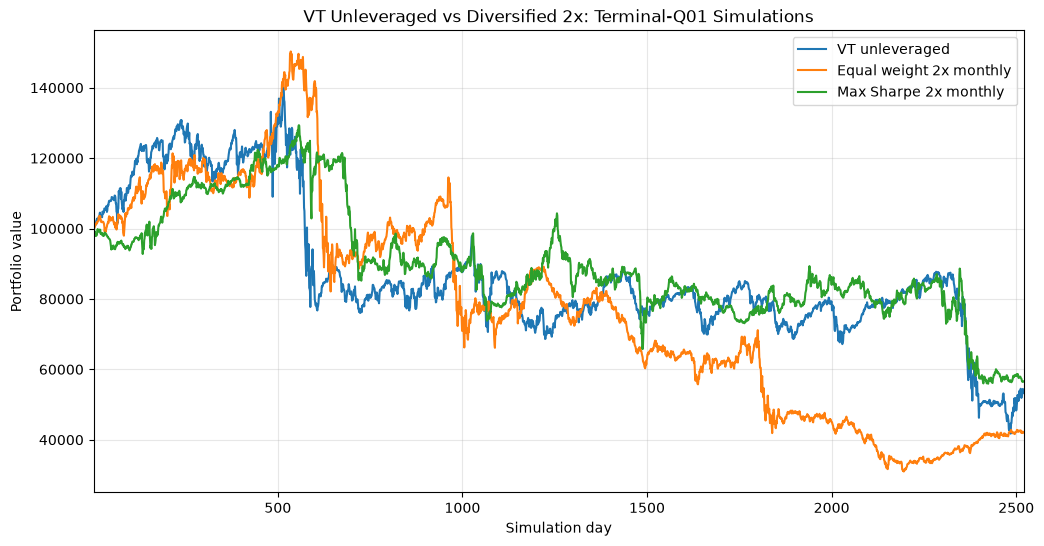

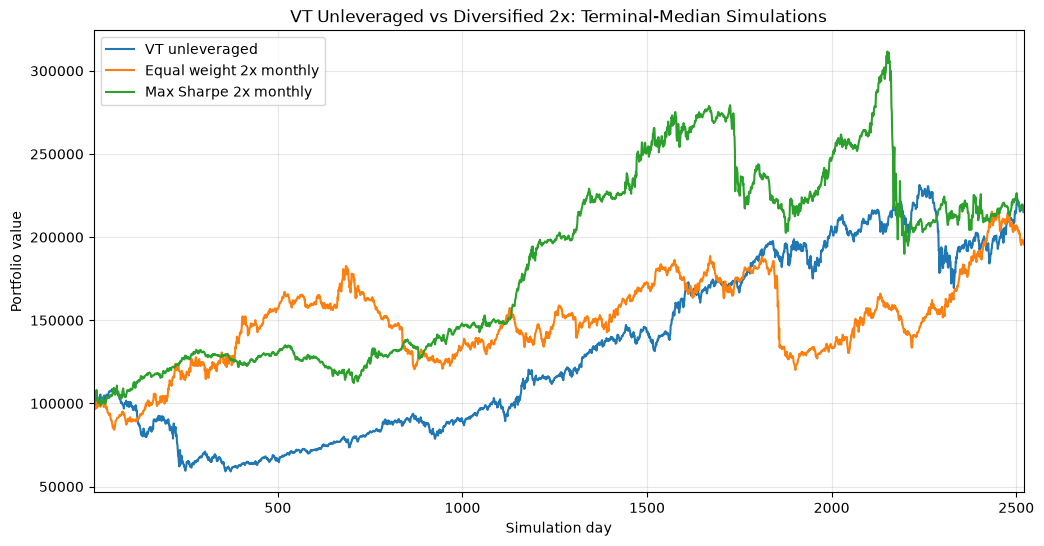

In [6]:
import importlib

import pandas as pd

import helpers.montecarlo as montecarlo

importlib.reload(montecarlo)

unlevered_paths = pd.read_parquet("output/mc_values_unlevered.parquet")
monthly_paths = pd.read_parquet("output/mc_values_leveraged_monthly.parquet")

q01_ax = montecarlo.plot_monthly_leverage_comparison(
    unlevered_paths,
    monthly_paths,
    quantile=0.01,
    title="VT Unleveraged vs Diversified 2x: Terminal-Q01 Simulations",
)
q01_ax.figure.savefig("output/monthly-montecarlo-q01.png", dpi=160, bbox_inches="tight")

median_ax = montecarlo.plot_monthly_leverage_comparison(
    unlevered_paths,
    monthly_paths,
    quantile=0.50,
    title="VT Unleveraged vs Diversified 2x: Terminal-Median Simulations",
)
median_ax.figure.savefig("output/monthly-montecarlo-median.png", dpi=160, bbox_inches="tight")